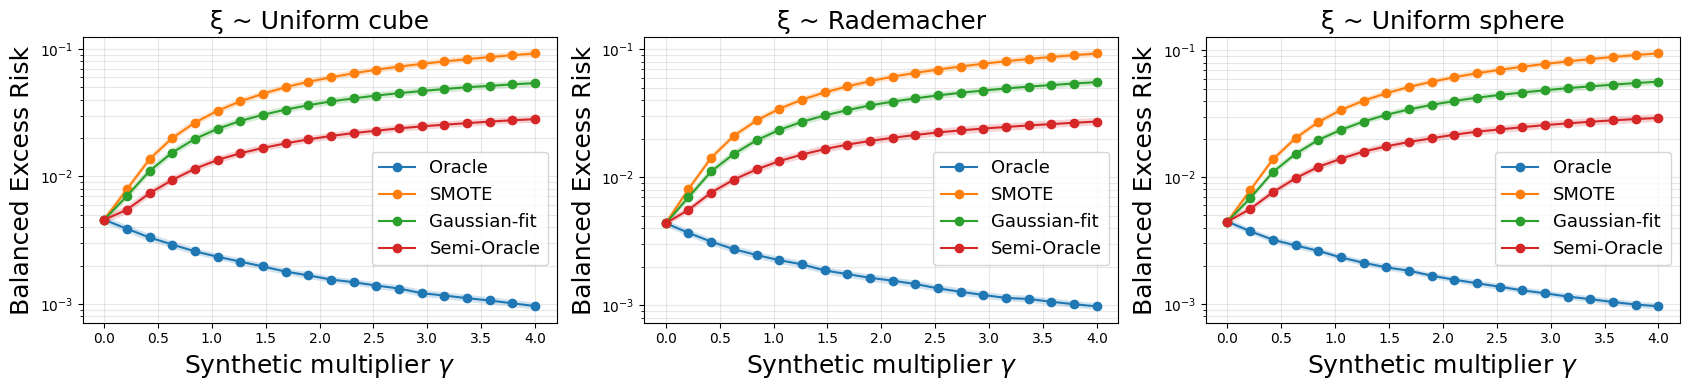

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def sample_U_uniform_cube(n, d, rng):
    a = np.sqrt(3.0)
    return rng.uniform(-a, a, size=(n, d))

def sample_U_rademacher(n, d, rng):
    return rng.choice([-1.0, 1.0], size=(n, d))

def sample_U_uniform_sphere(n, d, rng):
    g = rng.normal(size=(n, d))
    norms = np.linalg.norm(g, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    return g / norms * np.sqrt(d)

def precompute_smote_neighbors(minority_X, k=5):
    n_min = minority_X.shape[0]
    if n_min < 2:
        return None
    k_eff = min(k, n_min - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1)
    nn.fit(minority_X)
    neigh = nn.kneighbors(minority_X, return_distance=False)[:, 1:]
    return neigh  # shape (n_min, k_eff)

def smote_batch(minority_X, neigh, n_syn, rng):
    n_min, d = minority_X.shape
    if n_syn <= 0:
        return np.empty((0, d))

    if neigh is None:
        idx = rng.integers(0, n_min, size=n_syn)
        return minority_X[idx] + 1e-6 * rng.normal(size=(n_syn, d))

    k_eff = neigh.shape[1]
    base_idx = rng.integers(0, n_min, size=n_syn)
    pick = rng.integers(0, k_eff, size=n_syn)
    nb_idx = neigh[base_idx, pick]
    lam = rng.random(size=(n_syn, 1))

    xb = minority_X[base_idx]
    xn = minority_X[nb_idx]
    return xb + lam * (xn - xb)

def gaussian_fit_batch(minority_X, n_syn, rng, shrink=0.1, jitter=1e-6):
    if n_syn <= 0:
        return np.empty((0, minority_X.shape[1]))

    n_min, d = minority_X.shape
    m = minority_X.mean(axis=0)
    S = np.cov(minority_X, rowvar=False, bias=False)

    tr = np.trace(S) if np.isfinite(np.trace(S)) else d
    scale = tr / d if tr > 0 else 1.0
    S_shrunk = (1.0 - shrink) * S + shrink * scale * np.eye(d)

    S_shrunk = S_shrunk + jitter * np.eye(d)

    return rng.multivariate_normal(mean=m, cov=S_shrunk, size=n_syn)

def accumulate_stats_at_counts(X_all, counts):
    d = X_all.shape[1]
    stats = {}
    cumXtX = np.zeros((d, d))
    cumSum = np.zeros(d)

    prev = 0
    for k in counts:
        if k == 0:
            stats[0] = (cumXtX.copy(), cumSum.copy())
            continue

        if k > prev:
            chunk = X_all[prev:k]
            cumXtX += chunk.T @ chunk
            cumSum += chunk.sum(axis=0)
            prev = k

        stats[k] = (cumXtX.copy(), cumSum.copy())

    return stats

def run_mean_shift_experiment(sample_U,
                              d=20,
                              delta=1.0,
                              n0=2000,
                              n1=100,
                              gammas=None,
                              reps=200,
                              smote_k=5,
                              seed=0,
                              ridge=1e-8,
                              gauss_shrink=0.1):
    if gammas is None:
        gammas = np.linspace(0, 4, 17)
    gammas = np.array(gammas, dtype=float)
    n_syn_list = [int(np.round(g * (n0 - n1))) for g in gammas]
    unique_counts = sorted(set(n_syn_list))
    n_syn_max = max(unique_counts) if unique_counts else 0

    rng = np.random.default_rng(seed)

    mu = np.zeros(d)
    mu[0] = delta
    theta_star = mu / (1.0 + mu.dot(mu))
    R_star = (1.0 - theta_star.dot(mu))**2 + theta_star.dot(theta_star)

    M = 4
    excess = np.zeros((reps, len(gammas), M))
    I = np.eye(d)

    for r in range(reps):
        X0 = -mu + sample_U(n0, d, rng)
        X1 =  mu + sample_U(n1, d, rng)

        XtX_real = X0.T @ X0 + X1.T @ X1
        Xty_real = -X0.sum(axis=0) + X1.sum(axis=0)

        neigh = precompute_smote_neighbors(X1, k=smote_k)

        if n_syn_max > 0:
            X_oracle_all = mu + sample_U(n_syn_max, d, rng)
            rng.shuffle(X_oracle_all, axis=0)
            oracle_stats = accumulate_stats_at_counts(X_oracle_all, unique_counts)

            X_smote_all = smote_batch(X1, neigh, n_syn_max, rng)
            rng.shuffle(X_smote_all, axis=0)
            smote_stats = accumulate_stats_at_counts(X_smote_all, unique_counts)

            X_gauss_all = gaussian_fit_batch(X1, n_syn_max, rng, shrink=gauss_shrink)
            rng.shuffle(X_gauss_all, axis=0)
            gauss_stats = accumulate_stats_at_counts(X_gauss_all, unique_counts)

            mu_hat = X1.mean(axis=0)
            U_all = sample_U(n_syn_max, d, rng)
            X_knownU_all = mu_hat + U_all
            rng.shuffle(X_knownU_all, axis=0)
            knownU_stats = accumulate_stats_at_counts(X_knownU_all, unique_counts)

        else:
            Z = (np.zeros((d, d)), np.zeros(d))
            oracle_stats = {0: Z}
            smote_stats  = {0: Z}
            gauss_stats  = {0: Z}
            knownU_stats = {0: Z}

        for gi, n_syn in enumerate(n_syn_list):
            XtX_syn, Xsum_syn = oracle_stats[n_syn]
            theta = np.linalg.solve(XtX_real + XtX_syn + ridge * I, Xty_real + Xsum_syn)
            R = (1.0 - theta.dot(mu))**2 + theta.dot(theta)
            excess[r, gi, 0] = R - R_star

            XtX_syn, Xsum_syn = smote_stats[n_syn]
            theta = np.linalg.solve(XtX_real + XtX_syn + ridge * I, Xty_real + Xsum_syn)
            R = (1.0 - theta.dot(mu))**2 + theta.dot(theta)
            excess[r, gi, 1] = R - R_star

            XtX_syn, Xsum_syn = gauss_stats[n_syn]
            theta = np.linalg.solve(XtX_real + XtX_syn + ridge * I, Xty_real + Xsum_syn)
            R = (1.0 - theta.dot(mu))**2 + theta.dot(theta)
            excess[r, gi, 2] = R - R_star

            XtX_syn, Xsum_syn = knownU_stats[n_syn]
            theta = np.linalg.solve(XtX_real + XtX_syn + ridge * I, Xty_real + Xsum_syn)
            R = (1.0 - theta.dot(mu))**2 + theta.dot(theta)
            excess[r, gi, 3] = R - R_star

    mean = excess.mean(axis=0)
    std = excess.std(axis=0, ddof=1)
    se = std / np.sqrt(reps)
    ci = 1.96 * se

    return {
        "gammas": gammas,
        "mean": mean,
        "ci": ci,
        "labels": ["Oracle", "SMOTE", "Gaussian-fit", "Semi-Oracle"],
    }

def main():
    d = 20
    delta = 1.0
    n0, n1 = 2000, 100
    gammas = np.linspace(0, 4, 20)
    reps = 100
    smote_k = 5
    seed = 0

    dists = [
        ("ξ ~ Uniform cube", sample_U_uniform_cube),
        ("ξ ~ Rademacher", sample_U_rademacher),
        ("ξ ~ Uniform sphere", sample_U_uniform_sphere),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)

    for ax, (name, sampler) in zip(axes, dists):
        out = run_mean_shift_experiment(
            sampler,
            d=d, delta=delta,
            n0=n0, n1=n1,
            gammas=gammas,
            reps=reps,
            smote_k=smote_k,
            seed=seed,
            gauss_shrink=0.1,
        )

        x = out["gammas"]
        eps = 1e-12 

        for m, lab in enumerate(out["labels"]):
            y = out["mean"][:, m]
            y_ci = out["ci"][:, m]
            ax.plot(x, y + eps, marker="o", label=lab)
            ax.fill_between(
                x,
                np.maximum(y - y_ci, 0) + eps,
                y + y_ci + eps,
                alpha=0.2
            )

        ax.set_title(name, fontsize=18)
        ax.set_xlabel(r"Synthetic multiplier $\gamma$", fontsize=18)
        ax.set_ylabel("Balanced Excess Risk", fontsize=18)
        ax.set_yscale("log")  # comment out for linear
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="center right", bbox_to_anchor=(1.0, 0.40), fontsize=13)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


[setup] alpha=0.855384, n_train=5000, R=100, |gammas|=21
[progress] 20/100 reps (realized n+= 570, n-= 4430, minority=1)
[progress] 40/100 reps (realized n+= 551, n-= 4449, minority=1)
[progress] 60/100 reps (realized n+= 569, n-= 4431, minority=1)
[progress] 80/100 reps (realized n+= 539, n-= 4461, minority=1)
[progress] 100/100 reps (realized n+= 579, n-= 4421, minority=1)


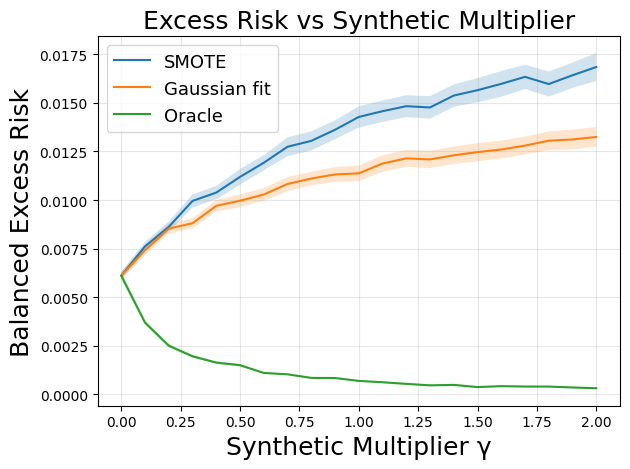

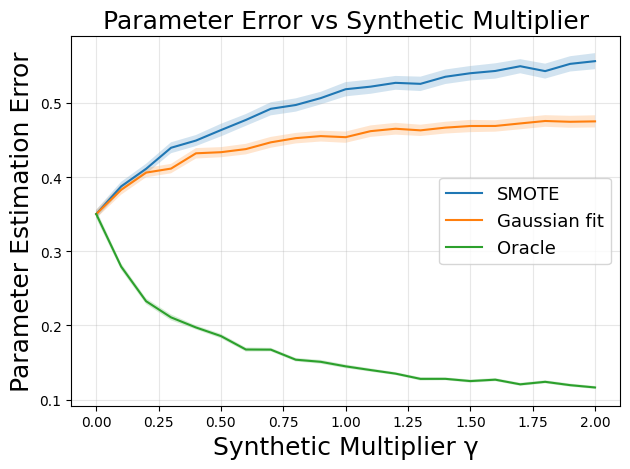

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from numpy.random import default_rng
from scipy.special import expit  # sigmoid
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors


def alpha_for_bias_cancellation(a: float, b: float, c: float) -> float:
    s_ca = expit(c * a)
    s_cb = expit(c * b)
    num = b * s_cb * (1 - s_cb)
    den = a * s_ca * (1 - s_ca) + b * s_cb * (1 - s_cb)
    return num / den


def sample_W_orthogonal(rng, n, d, sigma_w=1.0, mix_mu=2.5):
    W = np.zeros((n, d))
    if d <= 1:
        return W

    mu = np.zeros(d - 1)
    k = min(3, d - 1)
    mu[:k] = mix_mu

    signs = rng.choice([-1.0, 1.0], size=n)
    noise = rng.normal(size=(n, d - 1)) * sigma_w
    W[:, 1:] = noise + signs[:, None] * mu[None, :]
    return W


def make_example2_px_sampler(d=20, a=10.0, b=1.0, c=1.0, sigma_w=1.0, mix_mu=2.5):
    v = np.zeros(d)
    v[0] = 1.0
    theta_true = c * v
    alpha = alpha_for_bias_cancellation(a, b, c)

    def sample_X(rng, n):
        is_minus = rng.random(n) < alpha
        T = np.where(is_minus, -a, b).astype(float)
        W = sample_W_orthogonal(rng, n, d, sigma_w=sigma_w, mix_mu=mix_mu)
        return T[:, None] * v[None, :] + W

    def sample_Y_given_X(rng, X):
        p = expit(X @ theta_true)
        Y = np.where(rng.random(X.shape[0]) < p, 1, -1).astype(int)
        return Y

    return theta_true, alpha, sample_X, sample_Y_given_X

def fit_logreg(X, y_pm1):
    clf = LogisticRegression(
        penalty="l2",
        C=1e6,
        solver="lbfgs",
        max_iter=4000,
        fit_intercept=False,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf.fit(X, y_pm1)
    return clf.coef_.reshape(-1)


def balanced_logistic_risk(w, X_neg, X_pos):
    z_neg = X_neg @ w
    z_pos = X_pos @ w
    loss_neg = np.mean(np.logaddexp(0, z_neg)) 
    loss_pos = np.mean(np.logaddexp(0, -z_pos)) 
    return 0.5 * (loss_neg + loss_pos)

def smote_upsample(rng, X_min, n_target, k=5):
    n, d = X_min.shape
    if n_target <= n:
        return X_min.copy()

    n_syn = n_target - n

    if n < 3:
        idx = rng.integers(0, n, size=n_syn)
        return np.vstack([X_min, X_min[idx]])

    k_eff = min(k, n - 2)  
    n_neighbors = k_eff + 1

    nn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_min)
    neigh = nn.kneighbors(return_distance=False)[:, 1:] 
    idx_i = rng.integers(0, n, size=n_syn)
    idx_j = np.array([rng.choice(neigh[i]) for i in idx_i])
    u = rng.random(n_syn)

    X_syn = X_min[idx_i] + u[:, None] * (X_min[idx_j] - X_min[idx_i])
    return np.vstack([X_min, X_syn])


def gaussian_fit_upsample(rng, X_min, n_target, ridge=1e-6):
    n, d = X_min.shape
    if n_target <= n:
        return X_min.copy()

    n_syn = n_target - n
    mu = X_min.mean(axis=0)
    cov = np.cov(X_min, rowvar=False)
    tr = float(np.trace(cov)) if cov.ndim == 2 else 0.0
    cov = cov + (ridge * (tr / d if tr > 0 else 1.0)) * np.eye(d)
    X_syn = rng.multivariate_normal(mean=mu, cov=cov, size=n_syn)
    return np.vstack([X_min, X_syn])


def oracle_true_minority_upsample(rng, X_min, n_target, sample_X, sample_Y_given_X, y_min, batch=50000):
    n, d = X_min.shape
    if n_target <= n:
        return X_min.copy()

    n_syn = n_target - n
    syn_list = []
    got = 0
    cur_batch = batch

    while got < n_syn:
        Xb = sample_X(rng, cur_batch)
        yb = sample_Y_given_X(rng, Xb)
        keep = Xb[yb == y_min]
        if keep.shape[0] > 0:
            need = n_syn - got
            syn_list.append(keep[:need])
            got += min(need, keep.shape[0])
        if got < n_syn and keep.shape[0] == 0 and cur_batch < 500000:
            cur_batch *= 2

    X_syn = np.vstack(syn_list)
    return np.vstack([X_min, X_syn])

def sample_train_once(rng, n_train, sample_X, sample_Y_given_X, min_per_class=2):
    for _ in range(60):
        X = sample_X(rng, n_train)
        y = sample_Y_given_X(rng, X)
        n_pos = np.sum(y == 1)
        n_neg = np.sum(y == -1)
        if n_pos >= min_per_class and n_neg >= min_per_class:
            return X, y
    raise RuntimeError("Could not sample both classes. Increase n_train or reduce imbalance (e.g., smaller a).")


def sample_balanced_dataset(rng, n_per_class, sample_X, sample_Y_given_X, batch=50000):
    X_neg_list, X_pos_list = [], []
    got_neg = got_pos = 0

    while got_neg < n_per_class or got_pos < n_per_class:
        Xb = sample_X(rng, batch)
        yb = sample_Y_given_X(rng, Xb)

        if got_neg < n_per_class:
            take = Xb[yb == -1]
            need = n_per_class - got_neg
            if take.shape[0] > 0:
                X_neg_list.append(take[:need])
                got_neg += min(need, take.shape[0])

        if got_pos < n_per_class:
            take = Xb[yb == 1]
            need = n_per_class - got_pos
            if take.shape[0] > 0:
                X_pos_list.append(take[:need])
                got_pos += min(need, take.shape[0])

        if (got_neg + got_pos) < 10 and batch < 500000:
            batch *= 2

    return np.vstack(X_neg_list), np.vstack(X_pos_list)

def run_experiment(
    seed=0,
    d=20, a=5.0, b=1.0, c=1.0,
    sigma_w=1.0, mix_mu=2.5,
    n_train=5000,  
    gammas=np.linspace(0.0, 2.0, 21),
    R=100,
    n_star_per_class=20000,
    n_test_per_class=20000,
    smote_k=5,
):
    rng = default_rng(seed)
    theta_true, alpha, sample_X, sample_Y_given_X = make_example2_px_sampler(
        d=d, a=a, b=b, c=c, sigma_w=sigma_w, mix_mu=mix_mu
    )
    print(f"[setup] alpha={alpha:.6f}, n_train={n_train}, R={R}, |gammas|={len(gammas)}")

    X_neg_star, X_pos_star = sample_balanced_dataset(rng, n_star_per_class, sample_X, sample_Y_given_X)
    X_star = np.vstack([X_neg_star, X_pos_star])
    y_star = np.hstack([np.full(n_star_per_class, -1), np.full(n_star_per_class, 1)])
    theta_star = fit_logreg(X_star, y_star)

    X_neg_test, X_pos_test = sample_balanced_dataset(rng, n_test_per_class, sample_X, sample_Y_given_X)
    risk_star = balanced_logistic_risk(theta_star, X_neg_test, X_pos_test)

    excess_sm = np.zeros((R, len(gammas)))
    excess_ga = np.zeros((R, len(gammas)))
    excess_or = np.zeros((R, len(gammas)))

    perr_sm = np.zeros((R, len(gammas)))
    perr_ga = np.zeros((R, len(gammas)))
    perr_or = np.zeros((R, len(gammas)))

    for r in range(R):
        X, y = sample_train_once(rng, n_train, sample_X, sample_Y_given_X)

        n_pos = int(np.sum(y == 1))
        n_neg = int(np.sum(y == -1))

        if n_pos <= n_neg:
            y_min, y_maj = 1, -1
        else:
            y_min, y_maj = -1, 1

        X_min = X[y == y_min]
        X_maj = X[y == y_maj]
        n_min = X_min.shape[0]
        n_maj = X_maj.shape[0]
        gap = n_maj - n_min  # >= 0

        for j, gamma in enumerate(gammas):
            n_tilde = int(np.floor(gamma * gap))
            n_target_min = n_min + n_tilde

            X_min_sm = smote_upsample(rng, X_min, n_target_min, k=smote_k)
            X_sm = np.vstack([X_maj, X_min_sm])
            y_sm = np.hstack([np.full(X_maj.shape[0], y_maj), np.full(X_min_sm.shape[0], y_min)])
            w_sm = fit_logreg(X_sm, y_sm)

            X_min_ga = gaussian_fit_upsample(rng, X_min, n_target_min)
            X_ga = np.vstack([X_maj, X_min_ga])
            y_ga = np.hstack([np.full(X_maj.shape[0], y_maj), np.full(X_min_ga.shape[0], y_min)])
            w_ga = fit_logreg(X_ga, y_ga)

            X_min_or = oracle_true_minority_upsample(
                rng, X_min, n_target_min, sample_X, sample_Y_given_X, y_min
            )
            X_or = np.vstack([X_maj, X_min_or])
            y_or = np.hstack([np.full(X_maj.shape[0], y_maj), np.full(X_min_or.shape[0], y_min)])
            w_or = fit_logreg(X_or, y_or)

            excess_sm[r, j] = balanced_logistic_risk(w_sm, X_neg_test, X_pos_test) - risk_star
            excess_ga[r, j] = balanced_logistic_risk(w_ga, X_neg_test, X_pos_test) - risk_star
            excess_or[r, j] = balanced_logistic_risk(w_or, X_neg_test, X_pos_test) - risk_star

            perr_sm[r, j] = np.linalg.norm(w_sm - theta_star)
            perr_ga[r, j] = np.linalg.norm(w_ga - theta_star)
            perr_or[r, j] = np.linalg.norm(w_or - theta_star)

        if (r + 1) % max(1, R // 5) == 0:
            print(f"[progress] {r+1}/{R} reps (realized n+= {n_pos}, n-= {n_neg}, minority={y_min})")

    mean_ex_sm = excess_sm.mean(axis=0)
    mean_ex_ga = excess_ga.mean(axis=0)
    mean_ex_or = excess_or.mean(axis=0)

    mean_pe_sm = perr_sm.mean(axis=0)
    mean_pe_ga = perr_ga.mean(axis=0)
    mean_pe_or = perr_or.mean(axis=0)

    se_ex_sm = excess_sm.std(axis=0, ddof=1) / np.sqrt(R)
    se_ex_ga = excess_ga.std(axis=0, ddof=1) / np.sqrt(R)
    se_ex_or = excess_or.std(axis=0, ddof=1) / np.sqrt(R)

    se_pe_sm = perr_sm.std(axis=0, ddof=1) / np.sqrt(R)
    se_pe_ga = perr_ga.std(axis=0, ddof=1) / np.sqrt(R)
    se_pe_or = perr_or.std(axis=0, ddof=1) / np.sqrt(R)

    # Plot 1: excess risk
    plt.figure()
    plt.plot(gammas, mean_ex_sm, label="SMOTE")
    plt.plot(gammas, mean_ex_ga, label="Gaussian fit")
    plt.plot(gammas, mean_ex_or, label="Oracle")
    plt.fill_between(gammas, mean_ex_sm - se_ex_sm, mean_ex_sm + se_ex_sm, alpha=0.2)
    plt.fill_between(gammas, mean_ex_ga - se_ex_ga, mean_ex_ga + se_ex_ga, alpha=0.2)
    plt.fill_between(gammas, mean_ex_or - se_ex_or, mean_ex_or + se_ex_or, alpha=0.2)
    plt.xlabel("Synthetic Multiplier γ", fontsize=18)
    plt.ylabel("Balanced Excess Risk", fontsize=18)
    plt.title("Excess Risk vs Synthetic Multiplier", fontsize=18)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=13)
    plt.tight_layout()

    # Plot 2: parameter error
    plt.figure()
    plt.plot(gammas, mean_pe_sm, label="SMOTE")
    plt.plot(gammas, mean_pe_ga, label="Gaussian fit")
    plt.plot(gammas, mean_pe_or, label="Oracle")
    plt.fill_between(gammas, mean_pe_sm - se_pe_sm, mean_pe_sm + se_pe_sm, alpha=0.2)
    plt.fill_between(gammas, mean_pe_ga - se_pe_ga, mean_pe_ga + se_pe_ga, alpha=0.2)
    plt.fill_between(gammas, mean_pe_or - se_pe_or, mean_pe_or + se_pe_or, alpha=0.2)
    plt.xlabel("Synthetic Multiplier γ", fontsize=18)
    plt.ylabel("Parameter Estimation Error", fontsize=18)
    plt.title("Parameter Error vs Synthetic Multiplier", fontsize=18)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=13)
    plt.tight_layout()

    plt.show()


if __name__ == "__main__":
    run_experiment() 
